Load Packages and settings

In [1]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    mask_size = '892'
elif reg == 'SR':
    columnname = str(54)
    mask_size = '961'

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"

#read all events 
event_list = np.loadtxt('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/sample_events53550.txt',dtype='str')

list_size = ['550','961','1773','3669','6941']
mask_size = '961'
# train_size = list_size[2]
# list_size = train_size
task_list = [
'sigmaMC',      
            ]


(100, 13387, 4)
(13387, 18)


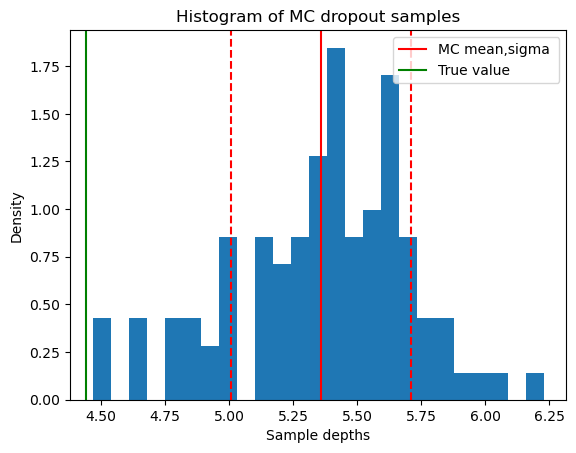

In [8]:
test_set= 2
event_id = 6750
site = 4
sample = np.load(f'{MLDir}/model/{reg}/sigmaMC/out/mc_samples_trainsize{list_size[0]}_testsize{test_set}_direct.npy')
tpe_table = pd.read_csv(f'{MLDir}/model/{reg}/sigmaMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_testsize{test_set}.csv')
print(sample.shape)
print(tpe_table.shape)
pt_sc_sample = sample[:,event_id,site-1]
tpe_sc = tpe_table.iloc[[event_id]]
#plot data
plt.hist(pt_sc_sample,bins=25,density=True)
plt.axvline(np.mean(pt_sc_sample),color='r',label='MC mean,sigma ')
plt.axvline(np.mean(pt_sc_sample)+np.std(pt_sc_sample),color='r',linestyle='--')
plt.axvline(np.mean(pt_sc_sample)-np.std(pt_sc_sample),color='r',linestyle='--')

#from stats of the normal model
plt.axvline(tpe_sc[f'T{site}'].values,color='g',label='True value')
plt.xlabel('Sample depths')
plt.ylabel('Density')
plt.title('Histogram of MC dropout samples')
plt.legend()
plt.show()

/tmp/ipykernel_3324264/2642199776.py:23: DtypeWarning: Columns (6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  master_info = pd.read_csv(f'{MLDir}/resources/processed/allinfo_eventsBS_PS53550.csv',sep=',')


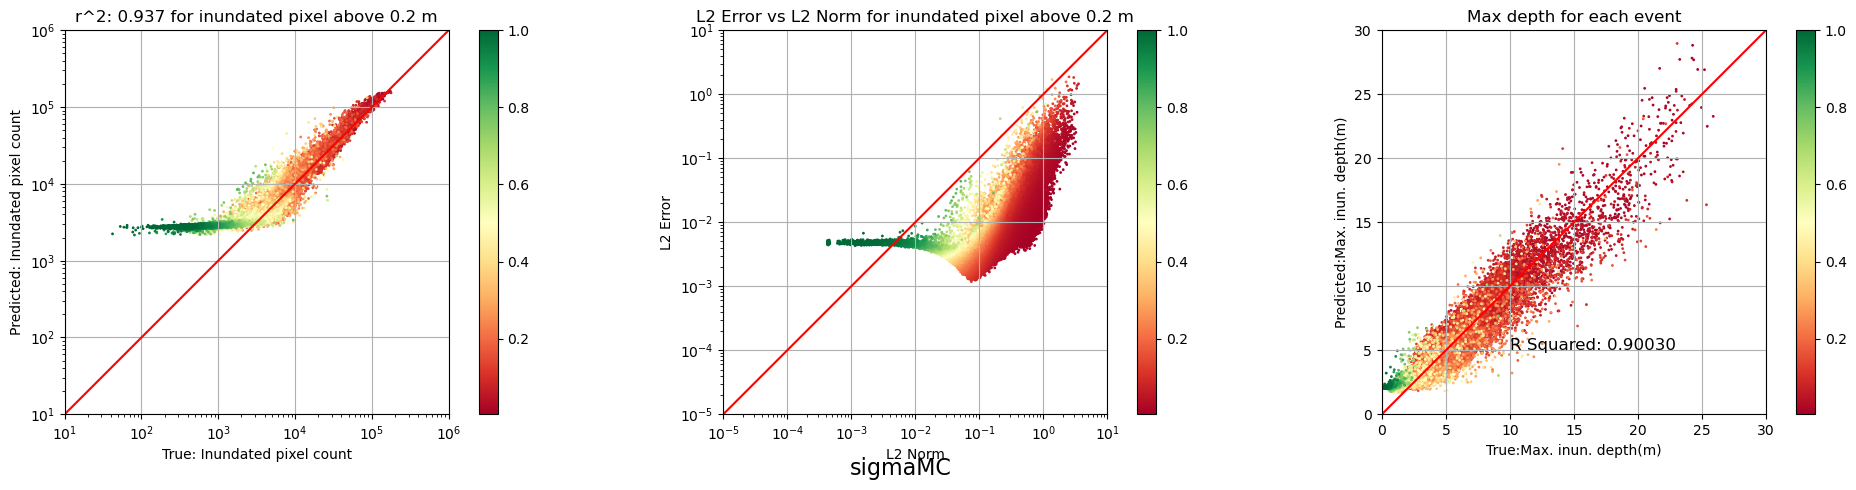

In [4]:
for task in task_list:
    for train_size in list_size[0:1]:
        perf_df_list = []
        loc_df_list = []
        for test_size in ['0', '1', '2', '3']:
            #read test performance events and append together rows to single dataframe
            file_perf = f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_testsize{test_size}.csv'
            file_loc = f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_testsize{test_size}.csv'
            df1 = pd.read_csv(file_perf)
            df2 = pd.read_csv(file_loc)
            perf_df_list.append(df1)
            loc_df_list.append(df2)

        perf_df = pd.concat(perf_df_list, ignore_index=True)
        loc_df = pd.concat(loc_df_list, ignore_index=True)
        #read train events to mark test or train
        train_file = f'{MLDir}/data/events/shuffled_events_{reg}_{train_size}.txt'
        train_eve = np.loadtxt(train_file, dtype='str')
        perf_df['split'] = np.where(perf_df['id'].isin(train_eve), 'train', 'test')
        loc_df['split'] = np.where(loc_df['id'].isin(train_eve), 'train', 'test')

        #read master info file to add more columns
        master_info = pd.read_csv(f'{MLDir}/resources/processed/allinfo_eventsBS_PS53550.csv',sep=',')
        master_info.rename(columns={'ID':'eve_id'},inplace=True)
        SR_info = pd.read_csv(f'{MLDir}/resources/processed/eve_PS_SourceRegion.txt',sep='\t')
        SR_info.rename(columns={'ID':'eve_id'},inplace=True)
        perf_df['Mag'] = perf_df['eve_id'].map(master_info.set_index('eve_id')['Mag'])
        perf_df['SR'] = perf_df['eve_id'].map(SR_info.set_index('eve_id')['SR'])
        perf_df['SR'].fillna('BS',inplace=True)   
        perf_df.to_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv', header=True, index=None)
        loc_df.to_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv', header=True, index=None)

        eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')
        eve_perf = eve_perf.sort_values(by='g',ascending=True)
        
        # Create a single figure with three axes
        fig, ax = plt.subplots(1, 3, figsize=(20, 5))

        # Plot scatter of flood count
        r2area = r2_score(eve_perf['true'], eve_perf['pred'])
        scatter = ax[0].scatter(eve_perf['true'], eve_perf['pred'], s=1, c=eve_perf['g'], cmap='RdYlGn')
        ax[0].plot([0, 1], [0, 1], transform=ax[0].transAxes, color='red')
        ax[0].set_title(f"r^2: {r2area:.3f} for inundated pixel above 0.2 m")
        plt.colorbar(scatter, ax=ax[0])
        ax[0].set_aspect('equal', adjustable='box')
        ax[0].set_xscale('log')
        ax[0].set_yscale('log')
        ax[0].set_xlim(10, 1000000)
        ax[0].set_ylim(10, 1000000)
        ax[0].grid()
        ax[0].set_xlabel('True: Inundated pixel count')
        ax[0].set_ylabel('Predicted: Inundated pixel count')

        # Plot scatter of mse vs l2norm
        scatter = ax[1].scatter(eve_perf['l2n'], eve_perf['mse'], s=1, c=eve_perf['g'], cmap='RdYlGn')
        ax[1].plot([0, 1], [0, 1], transform=ax[1].transAxes, color='red')
        plt.colorbar(scatter, ax=ax[1])
        ax[1].set_title(f"L2 Error vs L2 Norm for inundated pixel above 0.2 m")
        ax[1].set_aspect('equal', adjustable='box')
        ax[1].set_xscale('log')
        ax[1].set_yscale('log')
        ax[1].set_xlim(.00001, 10)
        ax[1].set_ylim(.00001, 10)
        ax[1].grid()
        ax[1].set_xlabel('L2 Norm')
        ax[1].set_ylabel('L2 Error')

        # Plot scatter of max depth for each event
        # Calculate the point density
        x = eve_perf['truemax']
        y = eve_perf['predmax']
        r2maxdepth = r2_score(x, y)
        scatter = ax[2].scatter(x, y, s=1, c=eve_perf['g'], cmap='RdYlGn')#c=z,
        ax[2].plot([0, 1], [0, 1], transform=ax[2].transAxes, color='red')
        plt.colorbar(scatter, ax=ax[2])
        ax[2].set_title("Max depth for each event")
        ax[2].text(10, 5, f"R Squared: {r2maxdepth:.5f} ", fontsize=12)
        ax[2].set_aspect('equal', adjustable='box')
        ax[2].set_xlim(0, 30)
        ax[2].set_ylim(0, 30)
        ax[2].grid()
        plt.xlabel('True:Max. inun. depth(m)')
        plt.ylabel('Predicted:Max. inun. depth(m)')
        #add master title
        plt.suptitle(f"{task}", fontsize=16, y=0.02)

        # Adjust layout and add a suptitle to the main plot
        plt.tight_layout()
        # plt.suptitle(f"mseoverall: {mseoverall:.5f}, r2maxdepth: {r2maxdepth:.5f}, gfitoverall: {gfitoverall:.4f}, testsize: {self.test_size}", fontsize=16, y=0.02)
        plt.savefig(f'{MLDir}/model/{reg}/{task}/out/model_direct_[64, 128, 256]_on[16, 128, 128]_{train_size}_combined.png')

In [ ]:
for task in task_list:
    for train_size in list_size:
        for split in ['train', 'test']:
            eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

            # Create a single figure with three axes
            fig, ax = plt.subplots(1, 3, figsize=(20, 5))

            # Plot scatter of flood count
            #select only rows where split is train or test
            x = eve_perf[eve_perf['split'] == split]['true']
            y = eve_perf[eve_perf['split'] == split]['pred']
            x.reset_index(drop=True, inplace=True)
            y.reset_index(drop=True, inplace=True)
            r2area = r2_score(x, y)
            xy = np.vstack([x,y])
            z = gaussian_kde(xy)(xy)
            index = z.argsort()
            x, y, z = x[index], y[index], z[index]
            scatter = ax[0].scatter(x, y, c=z, s=1)
            ax[0].plot([0, 1], [0, 1], transform=ax[0].transAxes, color='red')
            ax[0].set_title(f"r^2: {r2area:.3f} for inundated pixel above 0.2 m")
            plt.colorbar(scatter, ax=ax[0])
            ax[0].set_aspect('equal', adjustable='box')
            ax[0].set_xscale('log')
            ax[0].set_yscale('log')
            ax[0].set_xlim(10, 1000000)
            ax[0].set_ylim(10, 1000000)
            ax[0].grid()
            ax[0].set_xlabel('True: Inundated pixel count')
            ax[0].set_ylabel('Predicted: Inundated pixel count')

            # Plot scatter of mse vs l2norm
            # Calculate the point density
            x = eve_perf[eve_perf['split'] == split]['l2n']
            y = eve_perf[eve_perf['split'] == split]['mse']
            x.reset_index(drop=True, inplace=True)
            y.reset_index(drop=True, inplace=True)
            xy = np.vstack([x,y])
            z = gaussian_kde(xy)(xy)
            index = z.argsort()
            x, y, z = x[index], y[index], z[index]
            scatter = ax[1].scatter(x, y, c=z, s=1)
            ax[1].plot([0, 1], [0, 1], transform=ax[1].transAxes, color='red')
            plt.colorbar(scatter, ax=ax[1])
            ax[1].set_title(f"L2 Error vs L2 Norm for inundated pixel above 0.2 m")
            ax[1].set_aspect('equal', adjustable='box')
            ax[1].set_xscale('log')
            ax[1].set_yscale('log')
            ax[1].set_xlim(.00001, 10)
            ax[1].set_ylim(.00001, 10)
            ax[1].grid()
            ax[1].set_xlabel('L2 Norm')
            ax[1].set_ylabel('L2 Error')

            # Plot scatter of max depth for each event
            # Calculate the point density
            x = eve_perf[eve_perf['split'] == split]['truemax']
            y = eve_perf[eve_perf['split'] == split]['predmax']
            x.reset_index(drop=True, inplace=True)
            y.reset_index(drop=True, inplace=True)
            r2maxdepth = r2_score(x, y)
            xy = np.vstack([x,y])
            z = gaussian_kde(xy)(xy)
            index = z.argsort()
            x, y, z = x[index], y[index], z[index]
            scatter = ax[2].scatter(x, y, c=z, s=1)
            ax[2].plot([0, 1], [0, 1], transform=ax[2].transAxes, color='red')
            plt.colorbar(scatter, ax=ax[2])
            ax[2].set_title("Max depth for each event")
            ax[2].text(10, 5, f"R Squared: {r2maxdepth:.5f} ", fontsize=12)
            ax[2].set_aspect('equal', adjustable='box')
            ax[2].set_xlim(0, 30)
            ax[2].set_ylim(0, 30)
            ax[2].grid()
            plt.xlabel('True:Max. inun. depth(m)')
            plt.ylabel('Predicted:Max. inun. depth(m)')
            #add master title
            plt.suptitle(f"{task}", fontsize=16, y=0.02)

            # Adjust layout and add a suptitle to the main plot
            plt.tight_layout()
            plt.suptitle(f"{task} {split}", fontsize=16, y=0.02)


In [ ]:
for task in task_list:
    for train_size in list_size:
            eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

            # Create a single figure with three axes
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))

            # Plot scatter of flood count
            x = eve_perf[eve_perf['split'] == 'test']['true']
            y = eve_perf[eve_perf['split'] == 'test']['pred']
            r2area = r2_score(x, y)
            scatter = ax[0].scatter(x, y, s=1,label='test', c='orange')
            #add r2 score at bottom right of axis
            ax[0].text(100,100,f"r^2 test: {r2area:.3f} ", fontsize=12)

            x = eve_perf[eve_perf['split'] == 'train']['true']
            y = eve_perf[eve_perf['split'] == 'train']['pred']
            r2area = r2_score(x, y)
            scatter = ax[0].scatter(x, y, s=1,label='train', c='blue')
            ax[0].text(100,50,f"r^2 train: {r2area:.3f} ", fontsize=12)

            ax[0].title.set_text(f"For predicting inundated pixels above 0.2 m")
            ax[0].plot([0, 1], [0, 1], transform=ax[0].transAxes, color='red')
            ax[0].set_aspect('equal', adjustable='box')
            ax[0].set_xscale('log')
            ax[0].set_yscale('log')
            ax[0].set_xlim(10, 1000000)
            ax[0].set_ylim(10, 1000000)
            ax[0].grid()
            ax[0].set_xlabel('True: Inundated pixel count')
            ax[0].set_ylabel('Predicted: Inundated pixel count')

            # Plot scatter of mse vs l2norm
            x = eve_perf[eve_perf['split'] == 'test']['l2n']
            y = eve_perf[eve_perf['split'] == 'test']['mse']
            scatter = ax[1].scatter(x, y, s=1,label='test', c='orange')

            x = eve_perf[eve_perf['split'] == 'train']['l2n']
            y = eve_perf[eve_perf['split'] == 'train']['mse']
            scatter = ax[1].scatter(x, y, s=1,label='train', c='blue')

            ax[1].plot([0, 1], [0, 1], transform=ax[1].transAxes, color='red')
            ax[1].set_title(f"L2 Error vs L2 Norm for inundated pixel above 0.2 m")
            ax[1].set_aspect('equal', adjustable='box')
            ax[1].set_xscale('log')
            ax[1].set_yscale('log')
            ax[1].set_xlim(.00001, 10)
            ax[1].set_ylim(.00001, 10)
            ax[1].grid()
            ax[1].set_xlabel('L2 Norm')
            ax[1].set_ylabel('L2 Error')

            # Plot scatter of max depth for each event
            # Calculate the point density

            x = eve_perf[eve_perf['split'] == 'test']['truemax']
            y = eve_perf[eve_perf['split'] == 'test']['predmax']
            scatter = ax[2].scatter(x, y, s=1,label='test', c='orange')
            r2maxdepth = r2_score(x, y)
            ax[2].text(10, 5, f"r^2 test: {r2maxdepth:.5f} ", fontsize=12)

            x = eve_perf[eve_perf['split'] == 'train']['truemax']
            y = eve_perf[eve_perf['split'] == 'train']['predmax']
            scatter = ax[2].scatter(x, y, s=1,label='train', c='blue')
            r2maxdepth = r2_score(x, y)
            ax[2].text(10, 2, f"r^2 train: {r2maxdepth:.5f} ", fontsize=12)

            ax[2].plot([0, 1], [0, 1], transform=ax[2].transAxes, color='red')
            ax[2].set_title("Max depth for each event")
            ax[2].set_aspect('equal', adjustable='box')
            ax[2].set_xlim(0, 30)
            ax[2].set_ylim(0, 30)
            ax[2].grid()
            plt.xlabel('True:Max. inun. depth(m)')
            plt.ylabel('Predicted:Max. inun. depth(m)')
            #add master title
            plt.suptitle(f"{task}", fontsize=16, y=0.02)

            # Adjust layout and add a suptitle to the main plot
            plt.tight_layout()


Compare PTHA curves with the given data

In [5]:
#fit a left truncated normal distribution to the data
from scipy.stats import truncnorm
from scipy.stats import norm

def q_normal(data,q1,q2):
    if len(data) <= 1:
        qmin, qmax, mu = 0, 0, 0
    else:
        # fit a normal distribution
        # mu, std = norm.fit(data)
        mu = 0 
        std = np.sqrt(np.sum((data - mu) ** 2, axis=0) / (data.shape[0] - 1))
        qmin,qmax = norm.ppf(q1, loc=mu, scale=std), norm.ppf(q2, loc=mu, scale=std)
    return qmin, qmax,mu

def q_ltrunc_normal(data,q1,q2):
    if len(data) <= 1:
        qmin, qmax, mu = 0, 0, 0
    else:
        #fit a left truncated normal distribution
        mu, std = norm.fit(data)
        #truncated normal distribution
        a, b = (data.min() - mu), np.inf
        ltuncnorm = truncnorm(a, b, loc=mu, scale=std)
        qmin,qmax = ltuncnorm.ppf(q1), ltuncnorm.ppf(q2)
    return qmin, qmax, mu

def update_depths(depth_data,depth_bins,qmin_tab,qmax_tab):
    #for each depth bin, update the depth data as error corrected depth and +/- error
    depth_data_low = np.zeros_like(depth_data)
    depth_data_high = np.zeros_like(depth_data)

    for i in range(len(depth_bins)-1):
        
        #get the index of the data points in the bin
        index = np.where((depth_data >= depth_bins[i]) & (depth_data < depth_bins[i+1]))[0]
        
        # #get the qmin and qmax of the bin
        # print(depth_bins[i],qmin_tab[i],qmax_tab[i])

        qmin = qmin_tab[i]
        qmax = qmax_tab[i]

        # print(depth_bins[i],qmin,qmax)
    
        #update the depth data
        depth_data_low[index] = depth_data[index] + qmin
        depth_data_high[index] = depth_data[index] + qmax

    #if negative depths, set to 0
    depth_data_low[depth_data_low < 0] = 0
    return depth_data_low, depth_data_high 

def exceedance_curve(thresholds, max_stage_point, rates): 
   # Annual Mean Rate of threshold exceedance 
   lambda_exc = np.zeros((len(thresholds), 1000)) 
   for threshold in range(len(thresholds)): 
       ix = np.array(np.where(max_stage_point > thresholds[threshold])).squeeze() 
       for j in range(1000): 
           #for index in ix: 
           lambda_exc[threshold, j] = lambda_exc[threshold, j] +  rates[ix,j].sum(axis=0) 
   #------------------------------------------------ 
   return lambda_exc 

def single_exceedance_curve(thresholds, max_stage_point, rates): 
   # Annual Mean Rate of threshold exceedance 
   lambda_exc = np.zeros((len(thresholds), )) 
   for threshold in range(len(thresholds)): 
       ix = np.array(np.where(max_stage_point > thresholds[threshold])).squeeze() 
       #for index in ix: 
       lambda_exc[threshold] = lambda_exc[threshold] +  rates[ix].sum(axis=0) 
   #------------------------------------------------ 
   return lambda_exc

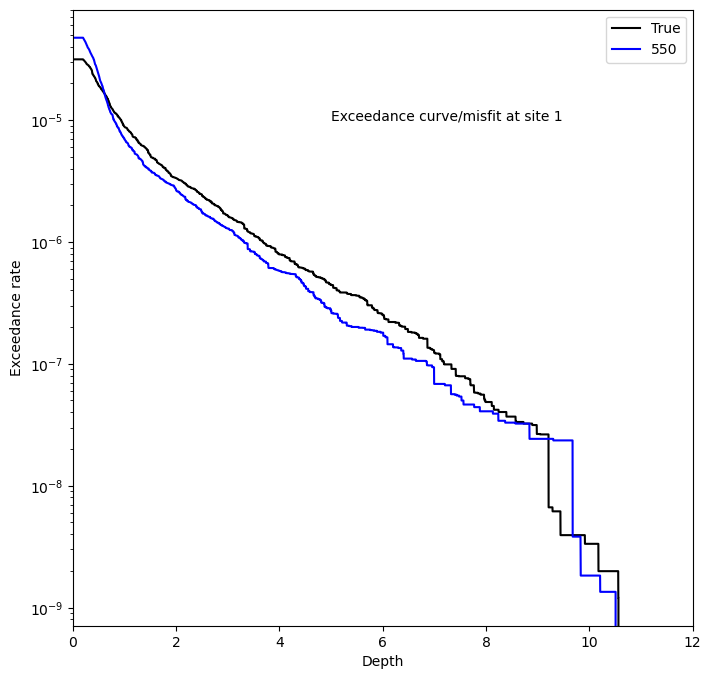

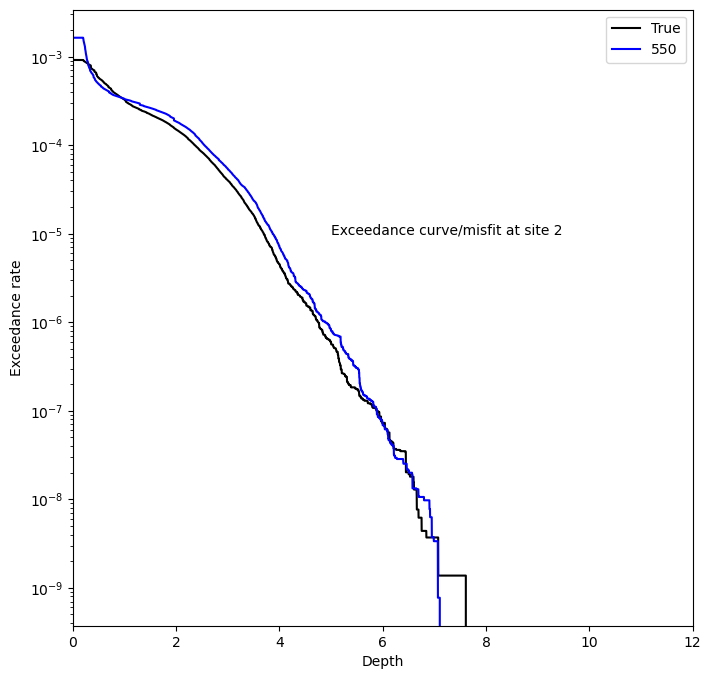

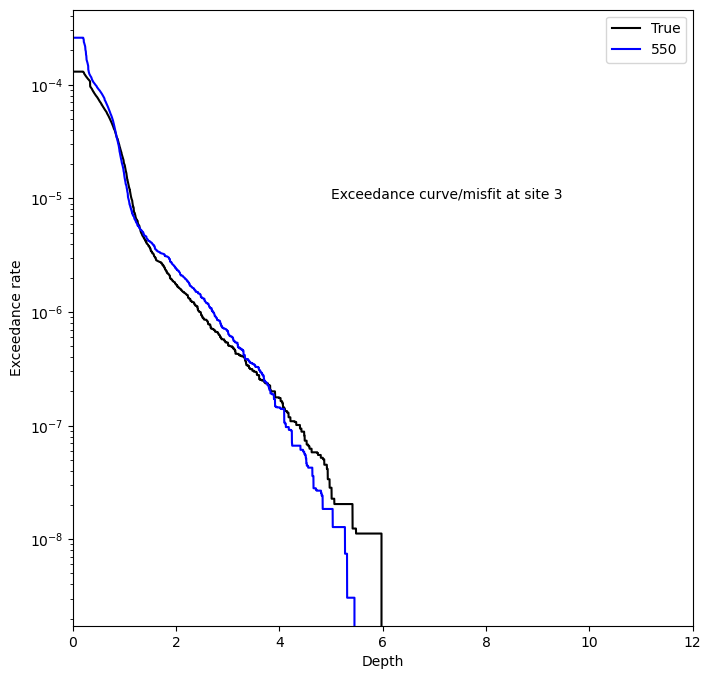

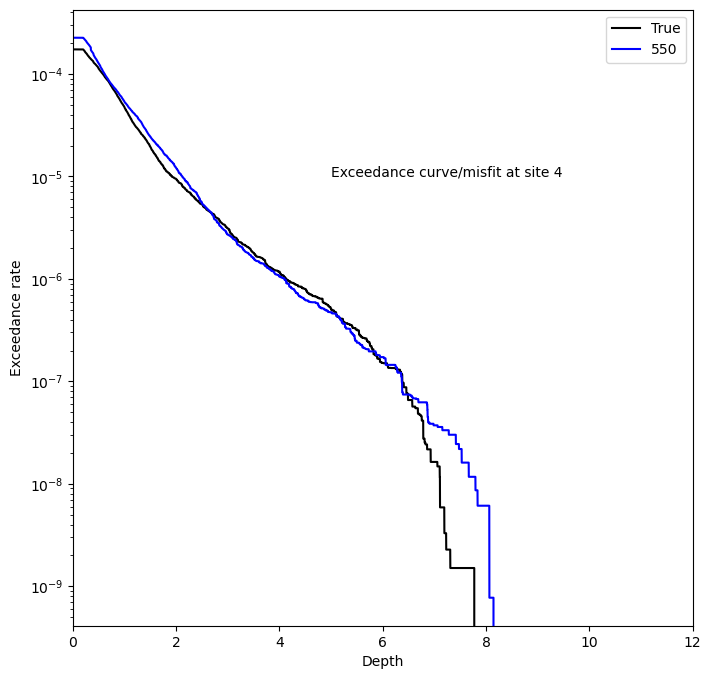

In [6]:
#get rates
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/{task_list[0]}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')
rate = eve_perf['mean_prob'].values

#compute depth thresholds 
thresholds_depth = np.linspace(0, 12, 5000)

#colors for different tasks
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'crimson', 'darkblue', 'darkgreen', 'darkred', 'darkpurple', 'darkorange', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkmagenta', 'darkyellow', 'darkcrimson']
styles = ['-', '--', ':', '-.', (0, (5, 10)), (0, (3, 1, 1, 1))]
#iterate over points
for select_pt in range(1, 5):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,ax = plt.subplots(1,1,figsize=(8,8))
    
    for t,task in enumerate(task_list):
        for s,train_size in enumerate(list_size[0:1]):
            eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
            
            #true
            if train_size == list_size[0] or train_size == list_size[2]:
                true = eve_dep_task['T'+select_pt].values
                lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
                ax.plot(thresholds_depth,lambda_exc_true, label='True', color='black')
            
            #predicted
            pred = eve_dep_task['P'+select_pt].values
            lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
            ax.plot(thresholds_depth,lambda_exc_pred, label=train_size, color=colors[s], linestyle=styles[s])
            ax.set_xlabel('Depth')
            ax.set_ylabel('Exceedance rate')
            ax.set_yscale('log')
            ax.set_xlim(0, 12)

    #legend outside plot
    ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))
    ax.text(5,0.00001,f'Exceedance curve/misfit at site {select_pt}',)
    plt.show()

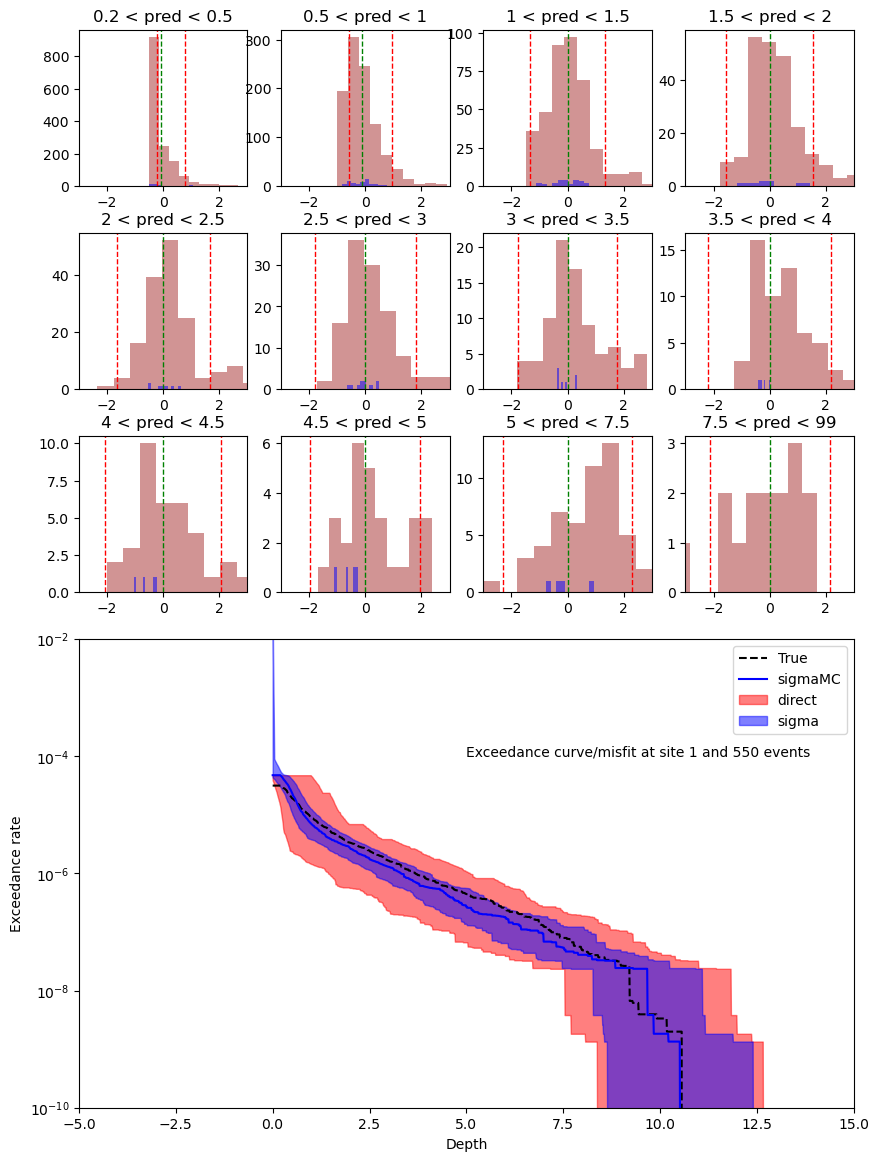

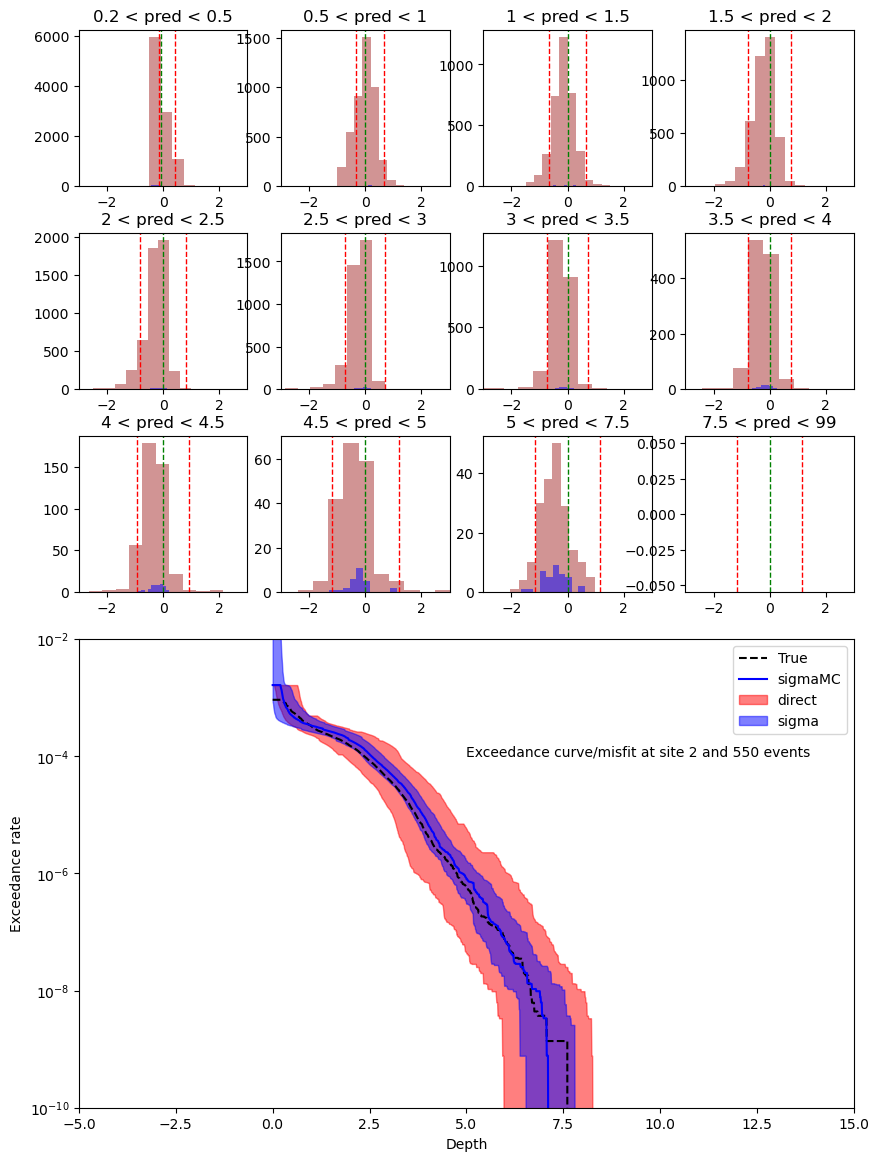

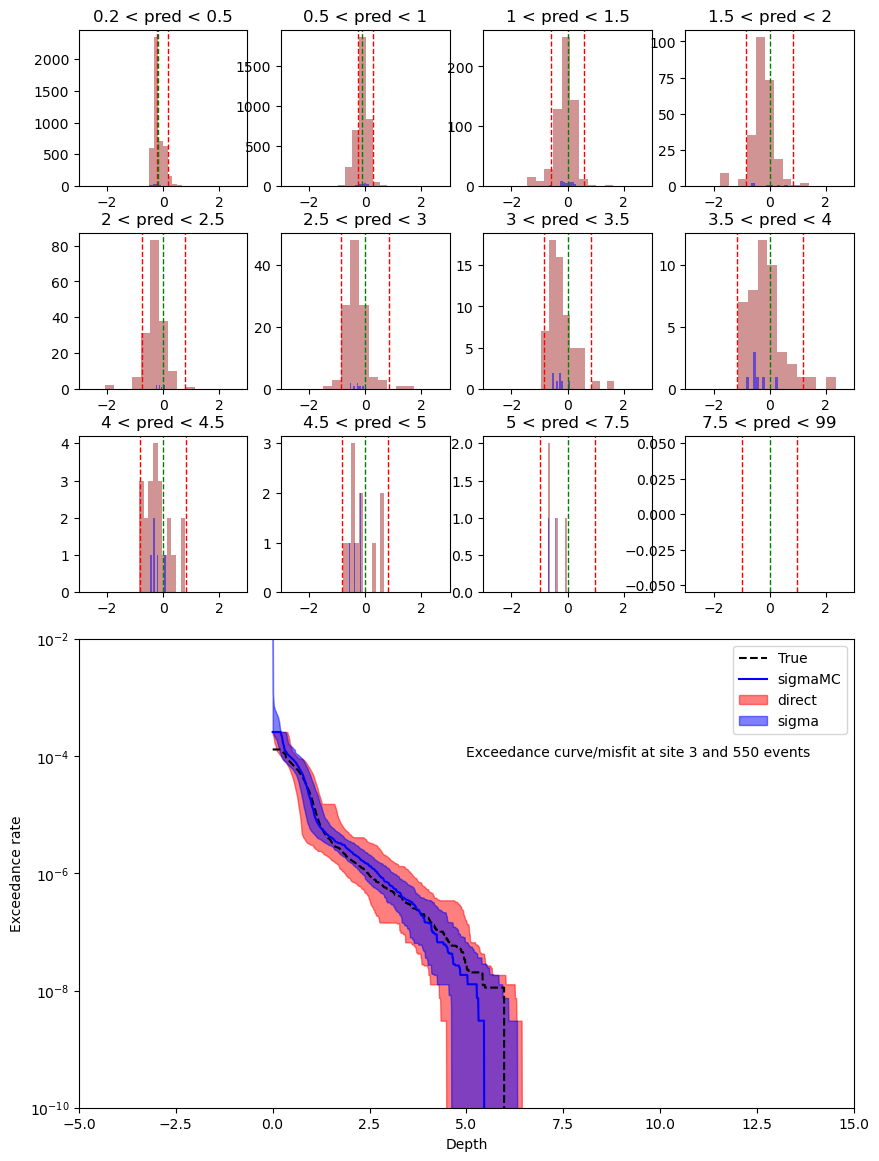

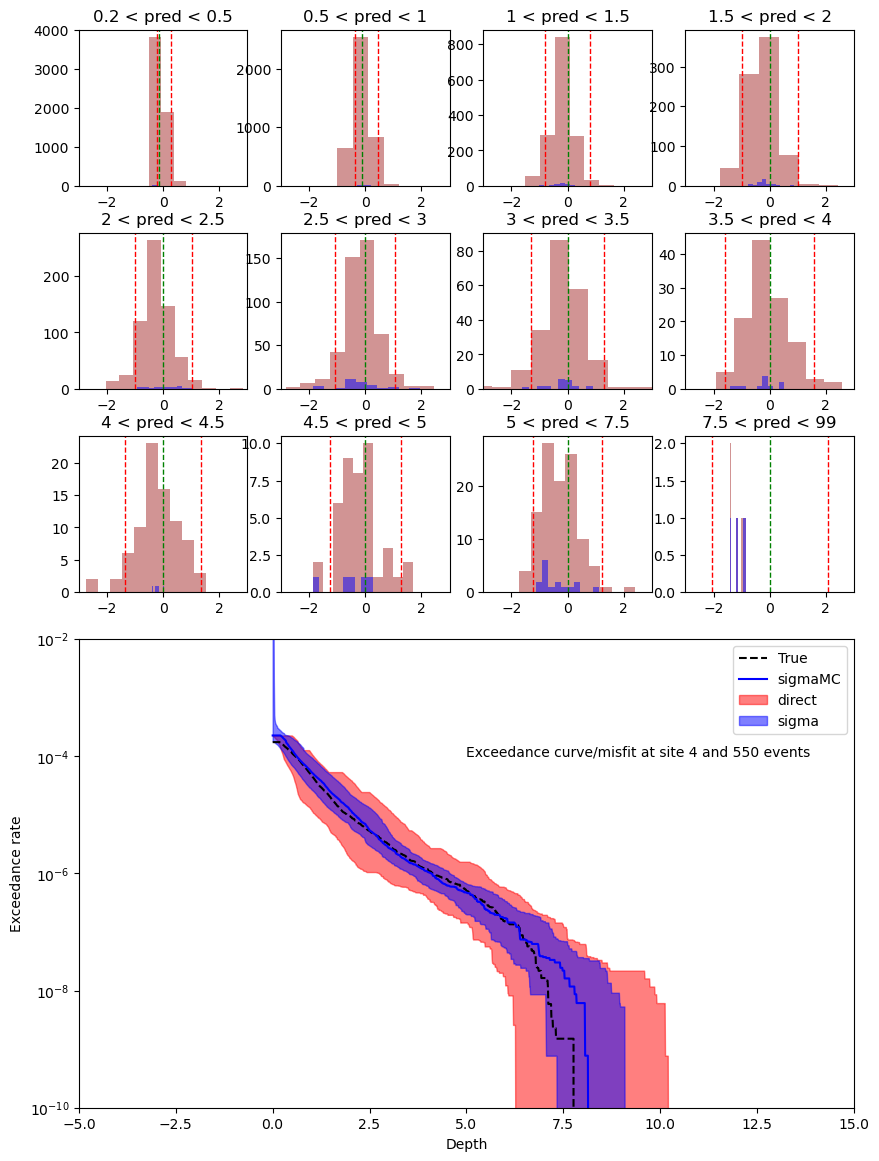

In [7]:
for train_size in list_size[0:1]:
    # train_size = list_size[0]
    #read train events to mark test or train
    train_sample = np.loadtxt(f'{MLDir}/data/events/shuffled_events_{reg}_{train_size}.txt', dtype='str')
    #get index of train events in event list
    event_index = np.array([np.where(event_list == train_sample[i])[0][0] for i in range(len(train_sample))])
    #first 75% of events are train and rest are test
    train_index = event_index[:int(len(event_index)*0.75)]
    test_index = event_index[int(len(event_index)*0.75):]

    #get rates
    eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/{task_list[0]}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')
    rate = eve_perf['mean_prob'].values

    #compute depth thresholds 
    thresholds_depth = np.linspace(0, 20, 2000)
    bins = [0.2,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,7.5,99]
    qlim=0.05,0.95

    #colors for different tasks
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'crimson', 'darkblue', 'darkgreen', 'darkred', 'darkpurple', 'darkorange', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkmagenta', 'darkyellow', 'darkcrimson']

    #iterate over points
    for select_pt in range(1, 5):
        select_pt = str(select_pt)

        #plot exceedance curve below and misfit in bins of 5 subplots
        fig,ax = plt.subplots(4,4,figsize=(10,14), gridspec_kw={'height_ratios': [1,1,1,3]})
        gs = ax[3,0].get_gridspec()
        for a in ax[3,:]:
            a.remove()
        axbig = fig.add_subplot(gs[3,:])

        for t,task in enumerate(task_list):
            eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
            
            #compute exceedance curve for true and predicted
            # if task == 'loss_func_MSE':
            true = eve_dep_task['T'+select_pt].values
            lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
            axbig.plot(thresholds_depth,lambda_exc_true, label='True', color='black', linestyle='dashed')
            
            #pred for a task
            pred = eve_dep_task['P'+select_pt].values
            sigma = eve_dep_task['R'+select_pt].values
            pred_m2sigma = pred - 2*sigma
            pred_p2sigma = pred + 2*sigma

            #error table
            qmin_table = []
            qmax_table = []
            
            # if task == 'mse_asym_band' or task == 'mse_asym_scalesq':

            for i,x in enumerate(bins):
                if i < len(bins)-1:
                    #plot histogram of error
                    error = eve_dep_task['E'+select_pt].values
                    
                    error_events = error[event_index] # use only train events
                    pred_events = pred[event_index] #use only train events

                    error_sel = error[(pred > bins[i]) & (pred < bins[i+1]) & (error != 0)]
                    error_train_sel = error_events[(error_events != 0) & (pred_events > bins[i]) & (pred_events < bins[i+1])]
                    
                    # #fit distribution with train events
                    # if i < 2:
                    #     #plot error quantiles
                    #     qmin,qmax,qmu = q_ltrunc_normal(error_train_sel,qlim[0],qlim[1])
                    # else:
                    #     qmin,qmax,qmu = q_normal(error_train_sel,qlim[0],qlim[1])

                    #fit distribution with all events
                    qmin,qmax,qmu = q_normal(error_sel,qlim[0],qlim[1])
                    if i < 2:
                        #plot error quantiles
                        qmin,qmax,qmu = q_ltrunc_normal(error_sel,qlim[0],qlim[1])
                    else:
                        qmin,qmax,qmu = q_normal(error_sel,qlim[0],qlim[1])
                    
                    #if no records take previous bin values
                    if i>0:
                        if qmin == 0:
                            qmin = qmin_table[i-1]
                        if qmax == 0:
                            qmax = qmax_table[i-1]

                    qmin_table.append(qmin)
                    qmax_table.append(qmax)
                    
                    # print(x, qmin, qmax, qmu)               
                    if i < 4:      
                        ax[0,i].set_title(f'{bins[i]} < pred < {bins[i+1]}')
                        ax[0,i].set_xlim(-3, 3)      
                        ax[0,i].hist(error_sel, bins=10, color=colors[5], alpha=0.5)
                        ax[0,i].hist(error_train_sel, bins=10, color=colors[0], alpha=0.5)
                        ax[0,i].axvline(qmin, color='r', linestyle='dashed', linewidth=1)
                        ax[0,i].axvline(qmax, color='r', linestyle='dashed', linewidth=1)
                        ax[0,i].axvline(qmu, color='g', linestyle='dashed', linewidth=1)
                    elif (i >= 4) & (i < 8):
                        ax[1,i-4].set_title(f'{bins[i]} < pred < {bins[i+1]}')
                        ax[1,i-4].set_xlim(-3, 3)      
                        ax[1,i-4].hist(error_sel, bins=10, color=colors[5], alpha=0.5)
                        ax[1,i-4].hist(error_train_sel, bins=10, color=colors[0], alpha=0.5)
                        ax[1,i-4].axvline(qmin, color='r', linestyle='dashed', linewidth=1)
                        ax[1,i-4].axvline(qmax, color='r', linestyle='dashed', linewidth=1)
                        ax[1,i-4].axvline(qmu, color='g', linestyle='dashed', linewidth=1)
                    else:
                        ax[2,i-8].set_title(f'{bins[i]} < pred < {bins[i+1]}')
                        ax[2,i-8].set_xlim(-3, 3)
                        ax[2,i-8].hist(error_sel, bins=10, color=colors[5], alpha=0.5)
                        ax[2,i-8].hist(error_train_sel, bins=10, color=colors[0], alpha=0.5)
                        ax[2,i-8].axvline(qmin, color='r', linestyle='dashed', linewidth=1)
                        ax[2,i-8].axvline(qmax, color='r', linestyle='dashed', linewidth=1)
                        ax[2,i-8].axvline(qmu, color='g', linestyle='dashed', linewidth=1)
                    
            #update depth data, set q missing to 0
            pred_low, pred_high = update_depths(pred, bins, qmin_table, qmax_table)
            # #some check to ensure pred_low < pred < pred_high
            pred_high[pred_high < pred] = pred[pred_high < pred]
            pred_low[pred_low > pred] = pred[pred_low > pred]

            #with direct error estimate
            lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
            lambda_exc_pred_low = single_exceedance_curve(thresholds_depth, pred_low, rate)
            lambda_exc_pred_high = single_exceedance_curve(thresholds_depth, pred_high, rate)
            #sigma estimates
            lambda_exc_pred_m2sigma = single_exceedance_curve(thresholds_depth, pred_m2sigma, rate)
            lambda_exc_pred_p2sigma = single_exceedance_curve(thresholds_depth, pred_p2sigma, rate)

            #some check to ensure lambda_exc_pred_low < lambda_exc_pred < lambda_exc_pred_high
            lambda_exc_pred_low[lambda_exc_pred_low > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_low > lambda_exc_pred]
            lambda_exc_pred_high[lambda_exc_pred_high < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_high < lambda_exc_pred]
            lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_m2sigma > lambda_exc_pred]
            lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_p2sigma < lambda_exc_pred]


            #set 0 as nan
            lambda_exc_pred_low[lambda_exc_pred_low == 0] = 1e-11
            lambda_exc_pred_high[lambda_exc_pred_high == 0] = 1e-11
            lambda_exc_pred[lambda_exc_pred == 0] = 1e-11
            lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma == 0] = 1e-11
            lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma == 0] = 1e-11

            #plot exceedance curves
            axbig.plot(thresholds_depth,lambda_exc_pred, label=task, color=colors[t])
            # axbig.plot(thresholds_depth,lambda_exc_pred_low, color='black')
            # axbig.plot(thresholds_depth,lambda_exc_pred_high, color='black')
            axbig.fill_between(thresholds_depth,lambda_exc_pred_high,lambda_exc_pred_low, color='r', alpha=0.5,label= 'direct')
            axbig.fill_between(thresholds_depth,lambda_exc_pred_p2sigma,lambda_exc_pred_m2sigma, color='b', alpha=0.5,label= 'sigma')
        
        axbig.set_xlabel('Depth')
        axbig.set_ylabel('Exceedance rate')
        axbig.set_yscale('log')
        axbig.set_xlim(-5, 15)
        axbig.set_ylim(1e-10, 1e-2)
        axbig.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))
        axbig.text(5,0.0001,f'Exceedance curve/misfit at site {select_pt} and {train_size} events',)
        plt.show()



In [ ]:
# #pick events greater than 5m at gauge 4
# select_pt = '4'
# true = eve_dep_mse['T'+select_pt].values
# eve_sel = eve_dep_mse[true > 5]
# eve_name = eve_sel['id']
# eve_perf_bad = eve_perf[eve_perf['id'].isin(eve_name)]

# #save events to csv
# eve_name.to_csv(f'bad_events.csv', header=True, index=None)

Control Points

[29720, 202349, 153030, 94497]
Control Location:1,No of flood events:2903/53550
Control Location:2,No of flood events:28895/53550
Control Location:3,No of flood events:6602/53550
Control Location:4,No of flood events:10843/53550


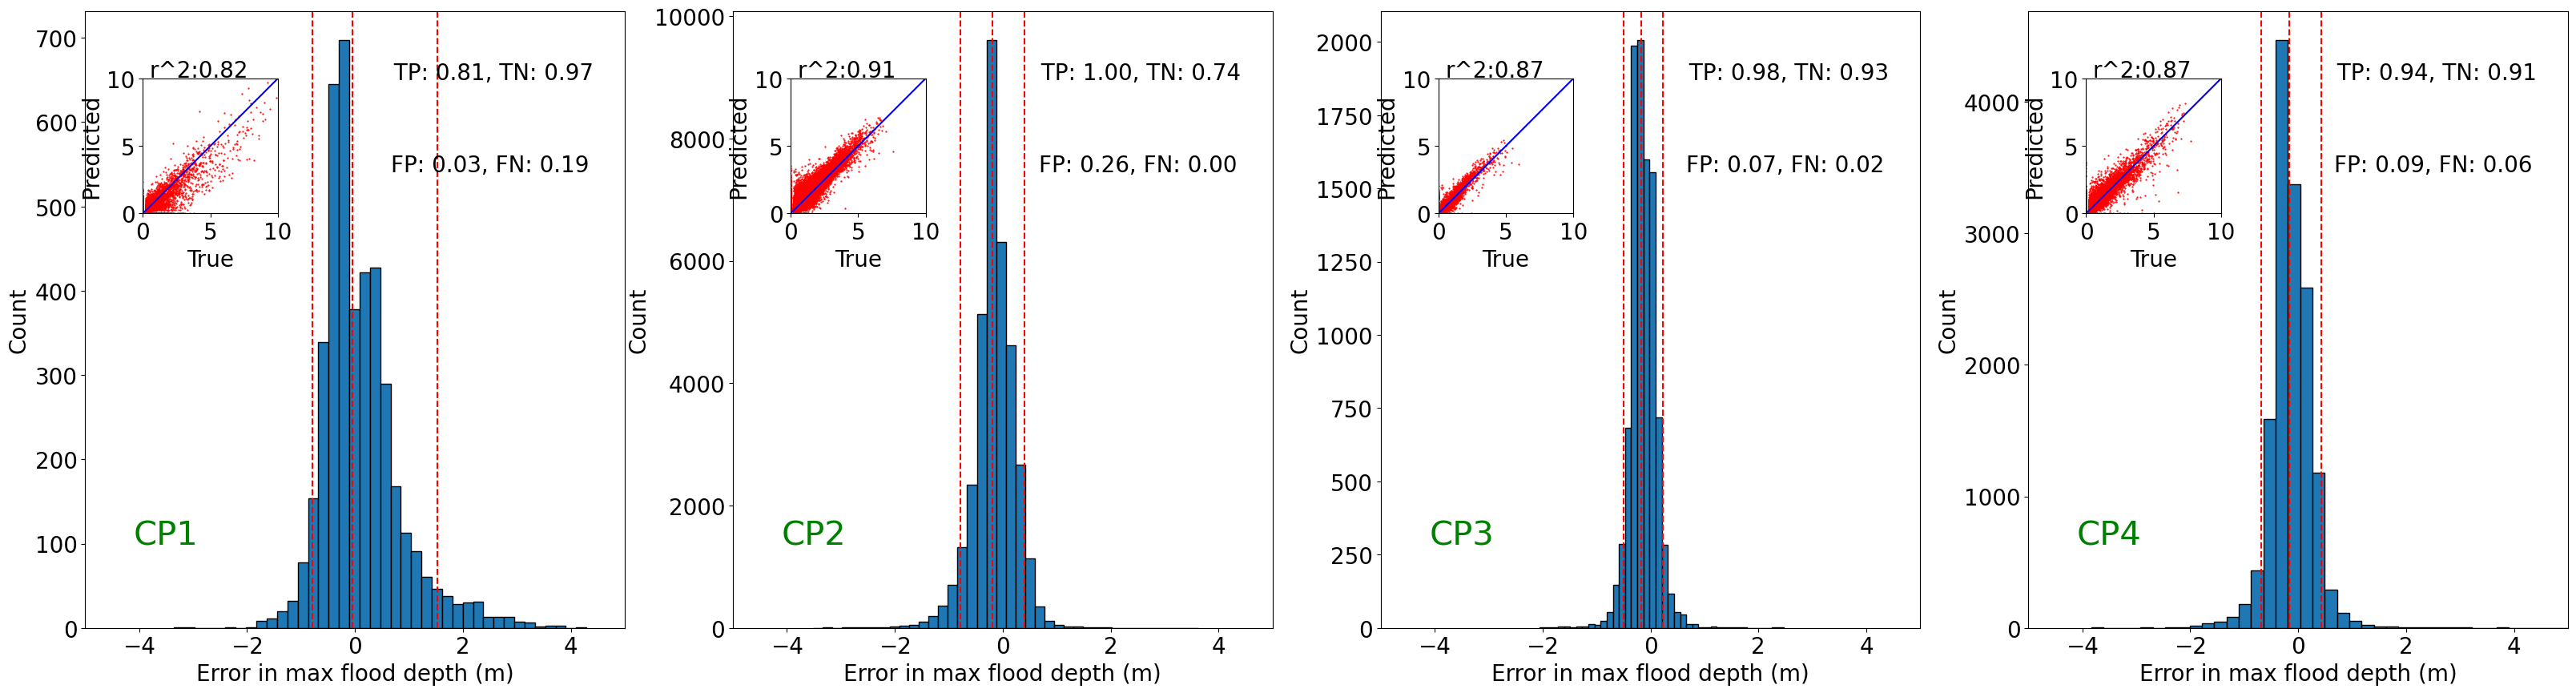

In [9]:
train_size = list_size[0]
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr

def get_idx_from_latlon(locations,reg,MLDir,SimDir,mask_size):  
    #get first event to get lat lon
    firstevent = np.loadtxt(f'{MLDir}/data/events/sample_events53550.txt',dtype='str')[0]
    D_grids = xr.open_dataset(f'{SimDir}/{firstevent}/{reg}_flowdepth.nc')
    zero_mask = np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
    non_zero_list = np.argwhere(~zero_mask).tolist()

    #iterate over list locations
    indices = []
    for loc in locations: 
        #get index of lat lon
        lat_idx = np.argmin(np.abs(D_grids.lat.values - loc[0]))
        lon_idx = np.argmin(np.abs(D_grids.lon.values - loc[1]))

        #get idx in non zero mask list from lat_idx and lon_idx
        idx = non_zero_list.index([lat_idx,lon_idx])
        indices.append(idx)

    # return lat_idx, lon_idx, idx
    print(indices)
    return indices

threshold = 0
control_points = [[37.01,15.29],
            [37.06757,15.28709],
            [37.05266,15.26536],
            [37.03211,15.28632]]
#[587734, 575410, 543846, 520437, 519950, 494033, 410933, 329708, 233614, 158611, 83994, 314698]

#keep every second element from the list
# control_points = control_points[::1]
locindices = get_idx_from_latlon(control_points,reg,MLDir,SimDir,mask_size)

true_pred_er = pd.read_csv(f'{MLDir}/model/{reg}/{task}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
#keep every second column from the dataframe
# true_pred_er = true_pred_er.iloc[:,::2]
#filter all columns with column name starting with E of true_pred_er
er_list = true_pred_er.iloc[:,true_pred_er.columns.str.startswith('E')].values 
#remove first and last column 
true_pred_er = true_pred_er.iloc[:,1:-1].values

#error charts
plt.figure(figsize=(40, 10))
for i in range(len(locindices)):
    ax = plt.subplot(1, 4, i+1)
    # Plot the histogram of errors for the control locations
    plt.hist(er_list[er_list[:,i]!=0,i],bins=40,edgecolor='black',)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    # Check if its empty
    if len(er_list[er_list[:,i]!=0,i]) == 0:
        continue
    else:
        quantiles = np.percentile(er_list[er_list[:,i]!=0,i], [5, 50, 95])
        # Plot quantile lines
        for q in quantiles:
            ax.axvline(q, color='red', linestyle='--', label=f'Q{int(q)}')
        ax.set_xlim(-5, 5)
    #calculate hit and mis for each location based on depth of true and prediction
    #events crossing the threshold say 0.2 are considered flooded
    neve = np.count_nonzero(true_pred_er[:,i]>threshold)
    neve_recon = np.count_nonzero(true_pred_er[:,i+len(locindices)]>threshold)
    print(f"Control Location:{i+1},No of flood events:{neve}/{len(true_pred_er[:,i])}")
    if neve == 0:
        TP = -999
        FN = -999
    else:
    #true positive: true>0.2 and pred>0.2
        TP = np.count_nonzero((true_pred_er[:,i]>threshold) & (true_pred_er[:,i+len(locindices)]>threshold))/(neve)
        FN = np.count_nonzero((true_pred_er[:,i]>threshold) & (true_pred_er[:,i+len(locindices)]<=threshold))/(neve)
    TN = np.count_nonzero((true_pred_er[:,i]<=threshold) & (true_pred_er[:,i+len(locindices)]<=threshold))/(len(true_pred_er[:,i])-neve)
    FP = np.count_nonzero((true_pred_er[:,i]<=threshold) & (true_pred_er[:,i+len(locindices)]>threshold))/(len(true_pred_er[:,i])-neve)
    # plt.title(f"#flood events:True={neve}|Predicted={neve_recon}",fontsize=20)
    plt.text(0.15,0.15,f"CP{i+1}", horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes,fontsize=30,color='green')
    plt.text(0.75, 0.9, f" TP: {TP:.2f}, TN: {TN:.2f}", horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes,fontsize=20)
    plt.text(0.75, 0.75, f"FP: {FP:.2f}, FN: {FN:.2f}", horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes,fontsize=20)
    plt.xlabel('Error in max flood depth (m)',fontsize=20)
    plt.ylabel('Count',fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    # Create a new inset axis for the scatter plot
    axins = inset_axes(ax, width="25%", height="25%", loc='upper left', borderpad=5.2)
    # Scatter plot of values (replace with your data)
    axins.plot([0, 1], [0, 1], transform=axins.transAxes, color='blue')
    axins.scatter(true_pred_er[:,i], true_pred_er[:,i+len(locindices)], marker='o', color='red', label='Max Inun Depth',s=0.33)  # Customize marker and color as needed
    axins.text(0.5,10.1,f'r^2:{r2_score(true_pred_er[:,i], true_pred_er[:,i+len(locindices)]):.2f}',fontsize=20)
    axins.set_xlim(0, 10)  # Adjust x-axis limits for the scatter plot
    axins.set_ylim(0, 10)  # Adjust y-axis limits for the scatter plot
    axins.set_xticks([0, 5, 10])  # Adjust x-axis ticks for the scatter plot
    axins.set_yticks([0, 5, 10])  # Adjust y-axis ticks for the scatter plot
    axins.set_xlabel('True',fontsize=20)
    axins.set_ylabel('Predicted',fontsize=20)
    axins.set_aspect('equal', adjustable='box')
    axins.tick_params(axis='x', labelsize=20)
    axins.tick_params(axis='y', labelsize=20)
# plt.savefig(f'{MLDir}/model/{reg}/out/error_test_combined_{reg}_{train_size}_direct.png', transparent=False)